# Notebook 3 — Predictive Clustering: Humidity Estimation 💧

**Objective:** Predict the Humidity of a new daily environmental record using 
K-Means predictive clustering — without any regression model.

**The mechanism:**
- Humidity is hidden from the clustering entirely
- K-Means is trained on the remaining 7 features (train set only)
- Each cluster's mean Humidity is computed from training data
- A new record arrives with no Humidity value
- It is assigned to the nearest centroid by Euclidean distance
- Its predicted Humidity = that cluster's mean Humidity

**The centroid IS the prediction. No second model is used.**

**Evaluation:** Since actual Humidity exists in the test set, 
predictions are evaluated using MAE and RMSE in original units (%).

## Methodology Notes

This project uses unsupervised learning techniques to identify environmental patterns across cities and seasons.

The predictive clustering section follows a cluster-based estimation approach:
1. Environmental observations are grouped using clustering algorithms
2. Humidity values are estimated using cluster-level behavior

This approach is intended for environmental pattern approximation rather than traditional supervised regression.

Electricity consumption was excluded from clustering because it reflects infrastructure demand rather than localized atmospheric conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
 mean_absolute_error,
 mean_squared_error,
 silhouette_score,
 davies_bouldin_score
)
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.3f}'.format)
print('All imports OK.')

All imports OK.


## Feature Scaling

Environmental variables exist on different numerical scales. Since clustering algorithms rely on distance calculations, unscaled variables can dominate cluster formation.

StandardScaler was applied to normalize all numerical features and ensure equal contribution during clustering.

## Cell 1 — Load Data

In [2]:
df = pd.read_csv('../../Data/final/environment_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print('Shape :', df.shape)
print('Cities :', df['City'].unique().tolist())
print('Date range :', df['Date'].min().date(), '→', df['Date'].max().date())
print('Missing values:', df.isnull().sum().sum())
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '../../Data/final/environment_data.csv'

## Cell 2 — Define Target and Features

**Target:** `Humidity` — hidden from the clustering model entirely.

**Clustering features (7):** All daily environmental variables except Humidity.
- PM10 excluded: near-perfect multicollinearity with PM2.5 (r=0.987)
- Pressure excluded: elevation artifact, constant per city
- Temperature_max excluded: redundant with Temperature_mean
- Green_Space, Electricity Consumption excluded: constant per city, no daily variation
- isWeekend, Date excluded: temporal metadata, not environmental signal
- City, Season excluded: interpreted after clustering, not model inputs

In [ ]:
TARGET = 'Humidity'
FEATURES = ['PM2.5', 'O3', 'NO2', 'CO', 'SO2', 'Temperature_mean', 'Wind_speed']
META = ['City', 'Season', 'Date']

X_raw = df[FEATURES].copy()
y_raw = df[TARGET].copy()
meta = df[META].copy()

print(f'Clustering features ({len(FEATURES)}): {FEATURES}')
print(f'Target feature : {TARGET}')
print(f'\nTarget (Humidity) statistics:')
print(y_raw.describe().round(2).to_string())

Clustering features (7): ['PM2.5', 'O3', 'NO2', 'CO', 'SO2', 'Temperature_mean', 'Wind_speed']
Target feature     : Humidity

Target (Humidity) statistics:
count   2548.000
mean      64.620
std       15.050
min       16.560
25%       54.520
50%       65.000
75%       76.310
max       97.620


## Cell 3 — Train/Test Split

80/20 stratified split by City. Humidity (target) is split alongside features 
but is never used during model fitting — only during evaluation.
The scaler is fitted on X_train only to prevent data leakage.

In [ ]:
(
 X_train_raw, X_test_raw,
 y_train, y_test,
 meta_train, meta_test
) = train_test_split(
 X_raw, y_raw, meta,
 test_size=0.2,
 random_state=42,
 stratify=df['City']
)

# Scale features — fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'Train : {len(X_train):,} rows')
print(f'Test : {len(X_test):,} rows')
print(f'\nHumidity in train — mean: {y_train.mean():.2f}%, std: {y_train.std():.2f}%')
print(f'Humidity in test — mean: {y_test.mean():.2f}%, std: {y_test.std():.2f}%')

Train : 2,038 rows
Test  : 510 rows

Humidity in train — mean: 64.51%, std: 15.10%
Humidity in test  — mean: 65.06%, std: 14.87%


## Cell 4 — Optimal k Selection (Train Set Only)

We evaluate k using two criteria on the clustering features only:
- **Elbow method** — diminishing returns in inertia reduction
- **Silhouette Score** — cluster cohesion and separation

A third criterion unique to this task is also considered: 
the **Humidity variance within each cluster** (lower = better prediction accuracy).
More clusters → smaller within-cluster Humidity variance → more precise predictions.

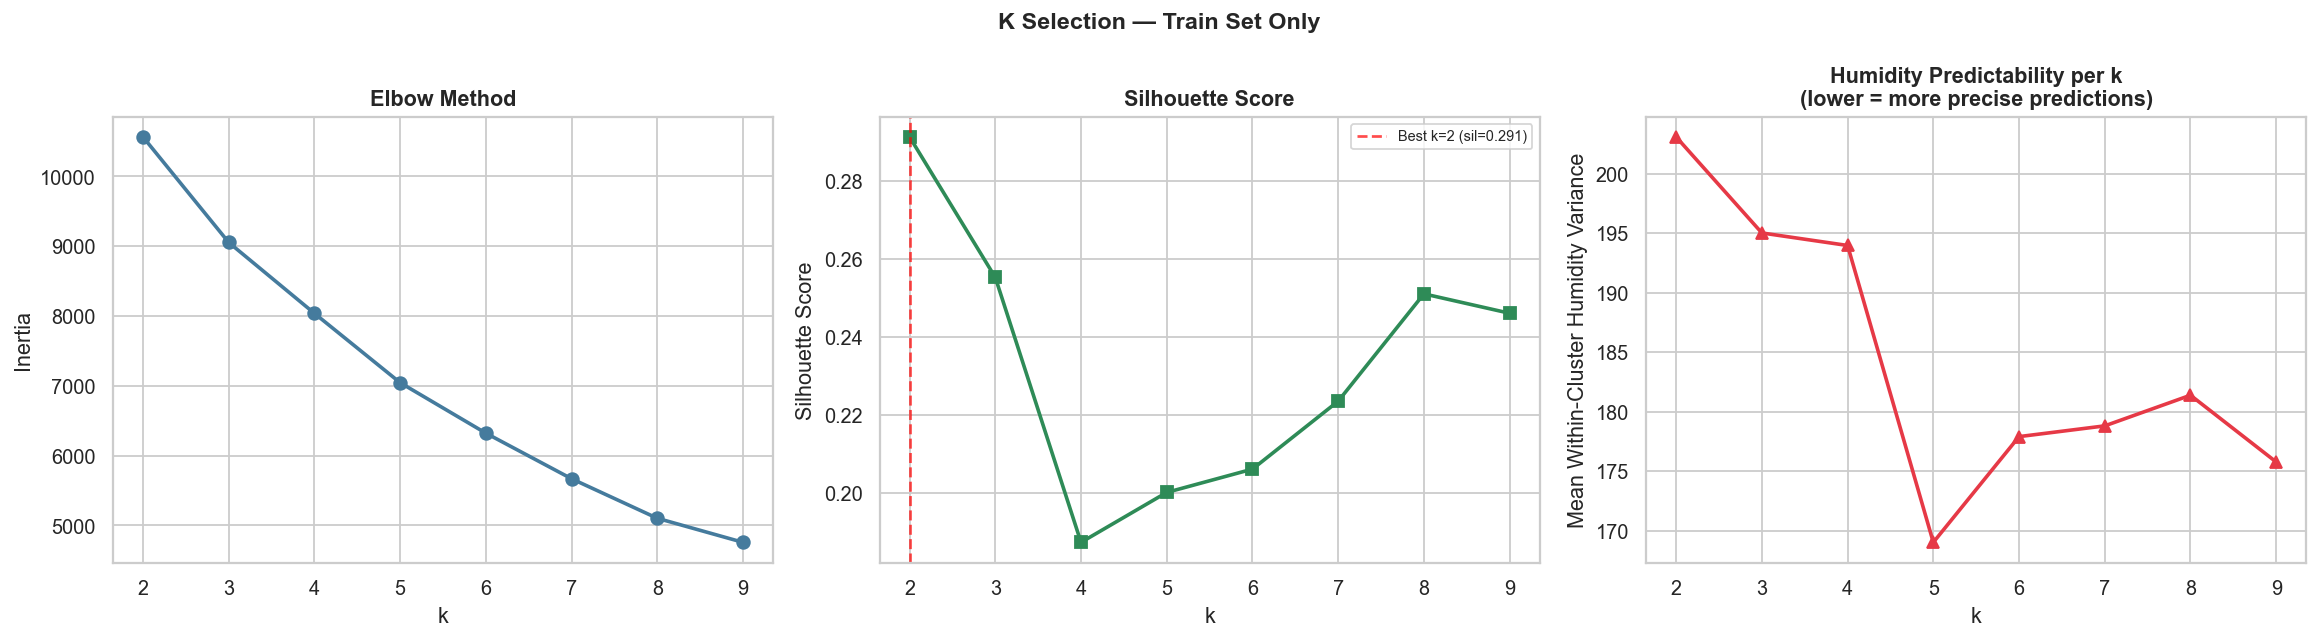

Best k by Silhouette         : 2

Within-cluster Humidity variance per k:
  k=2: 203.10
  k=3: 195.03
  k=4: 193.98
  k=5: 169.02
  k=6: 177.91
  k=7: 178.81
  k=8: 181.39
  k=9: 175.78


In [ ]:
k_range = range(2, 10)
inertias = []
sil_scores = []
hum_variances = [] # mean within-cluster Humidity variance per k

for k in k_range:
 km = KMeans(n_clusters=k, random_state=42, n_init=10)
 labels = km.fit_predict(X_train)
 inertias.append(km.inertia_)
 sil_scores.append(silhouette_score(X_train, labels, sample_size=500, random_state=42))

 # Within-cluster Humidity variance
 hum_df = pd.DataFrame({'label': labels, 'Humidity': y_train.values})
 within_var = hum_df.groupby('label')['Humidity'].var().mean()
 hum_variances.append(within_var)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=7, color='#457B9D')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

best_k_sil = k_range.start + sil_scores.index(max(sil_scores))
axes[1].plot(k_range, sil_scores, marker='s', linewidth=2, markersize=7, color='seagreen')
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7,
 label=f'Best k={best_k_sil} (sil={max(sil_scores):.3f})')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=8)

axes[2].plot(k_range, hum_variances, marker='^', linewidth=2, markersize=7, color='#E63946')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Mean Within-Cluster Humidity Variance')
axes[2].set_title('Humidity Predictability per k\n(lower = more precise predictions)', fontweight='bold')
axes[2].set_xticks(list(k_range))

plt.suptitle('K Selection — Train Set Only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best k by Silhouette : {best_k_sil}')
print(f'\nWithin-cluster Humidity variance per k:')
for k, v in zip(k_range, hum_variances):
 print(f' k={k}: {v:.2f}')

## Cell 5 — Fit Final K-Means Model

K-Means is fitted on the 7 clustering features (no Humidity).
After fitting, each cluster's **mean Humidity** is computed from training data.
This becomes the prediction value for any new record assigned to that cluster.

The OPTIMAL_K is set from the evidence above. Adjust if needed.

In [ ]:
OPTIMAL_K = best_k_sil # override manually if needed, e.g. OPTIMAL_K = 4

km_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
train_labels = km_model.fit_predict(X_train)

# Compute mean Humidity per cluster from training data
hum_df_train = pd.DataFrame({
 'Cluster' : train_labels,
 'Humidity': y_train.values,
 'City' : meta_train['City'].values,
 'Season' : meta_train['Season'].values
})

cluster_humidity = hum_df_train.groupby('Cluster')['Humidity'].agg(
 Mean='mean', Std='std', Min='min', Max='max', Count='count'
).round(2)

humidity_map = cluster_humidity['Mean'].to_dict()

print(f'K-Means fitted — k={OPTIMAL_K}')
print(f'Train Silhouette : {silhouette_score(X_train, train_labels, sample_size=500, random_state=42):.4f}')
print(f'Train DB Index : {davies_bouldin_score(X_train, train_labels):.4f}')
print(f'\nCluster Humidity profiles (used for prediction):')
print(cluster_humidity.to_string())
print(f'\nPrediction map (Cluster → Predicted Humidity):')
for cluster, hum in humidity_map.items():
 print(f' Cluster {cluster} → {hum:.2f}%')

K-Means fitted — k=2
Train Silhouette : 0.2912
Train DB Index   : 1.5372

Cluster Humidity profiles (used for prediction):
          Mean    Std    Min    Max  Count
Cluster                                   
0       57.470 14.450 19.530 97.620    714
1       68.310 14.050 27.000 96.310   1324

Prediction map (Cluster → Predicted Humidity):
  Cluster 0 → 57.47%
  Cluster 1 → 68.31%


## Cell 6 — Predict Humidity on Test Set

Each test record is assigned to the nearest centroid using `km_model.predict()`.
Its predicted Humidity is the mean Humidity of that cluster (from training data).
Actual Humidity values are then revealed for evaluation.

In [ ]:
test_labels = km_model.predict(X_test)
predicted_humidity = np.array([humidity_map[c] for c in test_labels])
actual_humidity = y_test.values

# Evaluation
mae = mean_absolute_error(actual_humidity, predicted_humidity)
rmse = np.sqrt(mean_squared_error(actual_humidity, predicted_humidity))
ss_res = np.sum((actual_humidity - predicted_humidity) ** 2)
ss_tot = np.sum((actual_humidity - actual_humidity.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Baseline: always predict the global mean Humidity
baseline_pred = np.full_like(actual_humidity, y_train.mean())
baseline_mae = mean_absolute_error(actual_humidity, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(actual_humidity, baseline_pred))

print('=== Humidity Prediction Results (Test Set) ===')
print(f'Records predicted : {len(test_labels):,}')
print()
print(f'MAE (cluster model): {mae:.2f}%')
print(f'RMSE (cluster model): {rmse:.2f}%')
print(f'R² (cluster model): {r2:.4f}')
print()
print(f'MAE (baseline mean): {baseline_mae:.2f}%')
print(f'RMSE (baseline mean): {baseline_rmse:.2f}%')
print()
print(f'MAE improvement over baseline : {baseline_mae - mae:.2f}% ({(baseline_mae-mae)/baseline_mae*100:.1f}% better)')
print(f'RMSE improvement over baseline : {baseline_rmse - rmse:.2f}% ({(baseline_rmse-rmse)/baseline_rmse*100:.1f}% better)')

=== Humidity Prediction Results (Test Set) ===
Records predicted    : 510

MAE   (cluster model): 11.52%
RMSE  (cluster model): 13.85%
R²    (cluster model): 0.1307

MAE   (baseline mean): 12.22%
RMSE  (baseline mean): 14.86%

MAE  improvement over baseline : 0.70% (5.7% better)
RMSE improvement over baseline : 1.01% (6.8% better)


## Cell 7 — Prediction vs Actual: Visual Evaluation

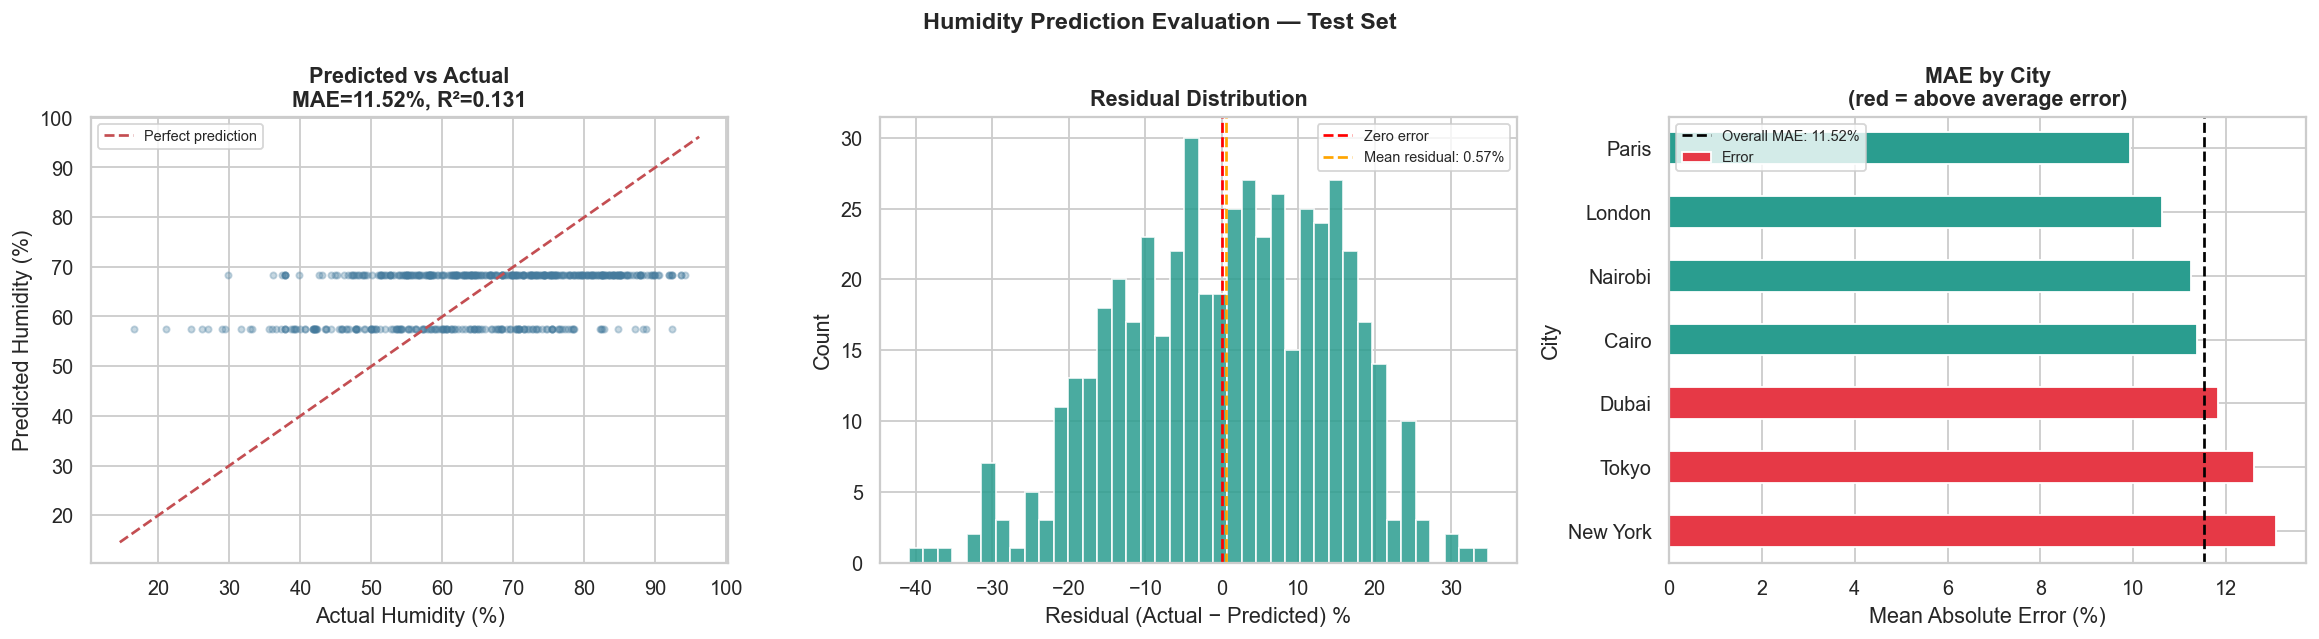

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: predicted vs actual
axes[0].scatter(actual_humidity, predicted_humidity, alpha=0.3, s=12, color='#457B9D')
lims = [min(actual_humidity.min(), predicted_humidity.min()) - 2,
 max(actual_humidity.max(), predicted_humidity.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Humidity (%)')
axes[0].set_ylabel('Predicted Humidity (%)')
axes[0].set_title(f'Predicted vs Actual\nMAE={mae:.2f}%, R²={r2:.3f}', fontweight='bold')
axes[0].legend(fontsize=8)

# 2. Residuals distribution
residuals = actual_humidity - predicted_humidity
axes[1].hist(residuals, bins=40, color='#2A9D8F', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
 label=f'Mean residual: {residuals.mean():.2f}%')
axes[1].set_xlabel('Residual (Actual − Predicted) %')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend(fontsize=8)

# 3. MAE per city
results_df = pd.DataFrame({
 'City' : meta_test['City'].values,
 'Season' : meta_test['Season'].values,
 'Actual' : actual_humidity,
 'Predicted': predicted_humidity,
 'Cluster' : test_labels,
 'Error' : np.abs(residuals)
})

mae_by_city = results_df.groupby('City')['Error'].mean().sort_values(ascending=False)
colors_bar = ['#E63946' if v > mae else '#2A9D8F' for v in mae_by_city]
mae_by_city.plot(kind='barh', ax=axes[2], color=colors_bar, edgecolor='white')
axes[2].axvline(mae, color='black', linestyle='--', linewidth=1.5,
 label=f'Overall MAE: {mae:.2f}%')
axes[2].set_xlabel('Mean Absolute Error (%)')
axes[2].set_title('MAE by City\n(red = above average error)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Humidity Prediction Evaluation — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 8 — Error Analysis by Season and Cluster

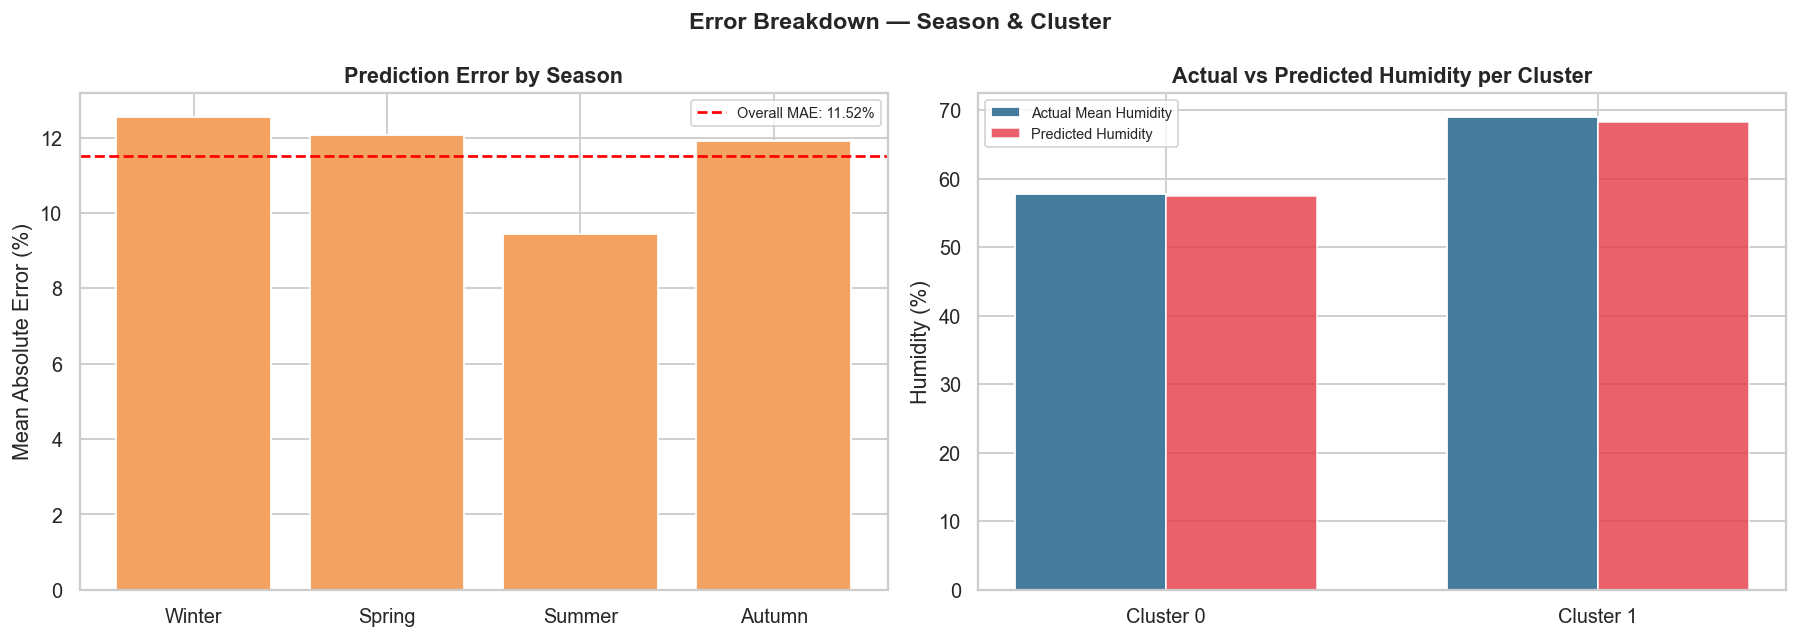

MAE by Season:
Season
Autumn   11.920
Spring   12.080
Summer    9.450
Winter   12.550

Cluster prediction summary:
         Actual_Mean  Predicted_Mean    MAE  Count
Cluster                                           
0             57.740          57.470 12.250    180
1             69.050          68.310 11.120    330


In [ ]:
# MAE by season
mae_by_season = results_df.groupby('Season')['Error'].mean().round(2)

# MAE by cluster
mae_by_cluster = results_df.groupby('Cluster')['Error'].mean().round(2)

# Within-cluster actual vs predicted humidity
cluster_summary = results_df.groupby('Cluster').agg(
 Actual_Mean = ('Actual', 'mean'),
 Predicted_Mean= ('Predicted', 'mean'),
 MAE = ('Error', 'mean'),
 Count = ('Actual', 'count')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Season MAE
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
mae_ordered = [mae_by_season.get(s, np.nan) for s in season_order]
axes[0].bar(season_order, mae_ordered, color='#F4A261', edgecolor='white')
axes[0].axhline(mae, color='red', linestyle='--', label=f'Overall MAE: {mae:.2f}%')
axes[0].set_ylabel('Mean Absolute Error (%)')
axes[0].set_title('Prediction Error by Season', fontweight='bold')
axes[0].legend(fontsize=8)

# Cluster actual vs predicted
x = np.arange(OPTIMAL_K)
width = 0.35
axes[1].bar(x - width/2, cluster_summary['Actual_Mean'],
 width, label='Actual Mean Humidity', color='#457B9D', edgecolor='white')
axes[1].bar(x + width/2, cluster_summary['Predicted_Mean'],
 width, label='Predicted Humidity', color='#E63946', edgecolor='white', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])
axes[1].set_ylabel('Humidity (%)')
axes[1].set_title('Actual vs Predicted Humidity per Cluster', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Error Breakdown — Season & Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('MAE by Season:')
print(mae_by_season.to_string())
print('\nCluster prediction summary:')
print(cluster_summary.to_string())

## Cell 9 — Cluster Interpretation

After predicting, we bring back City and Season metadata to understand 
what each cluster represents environmentally.

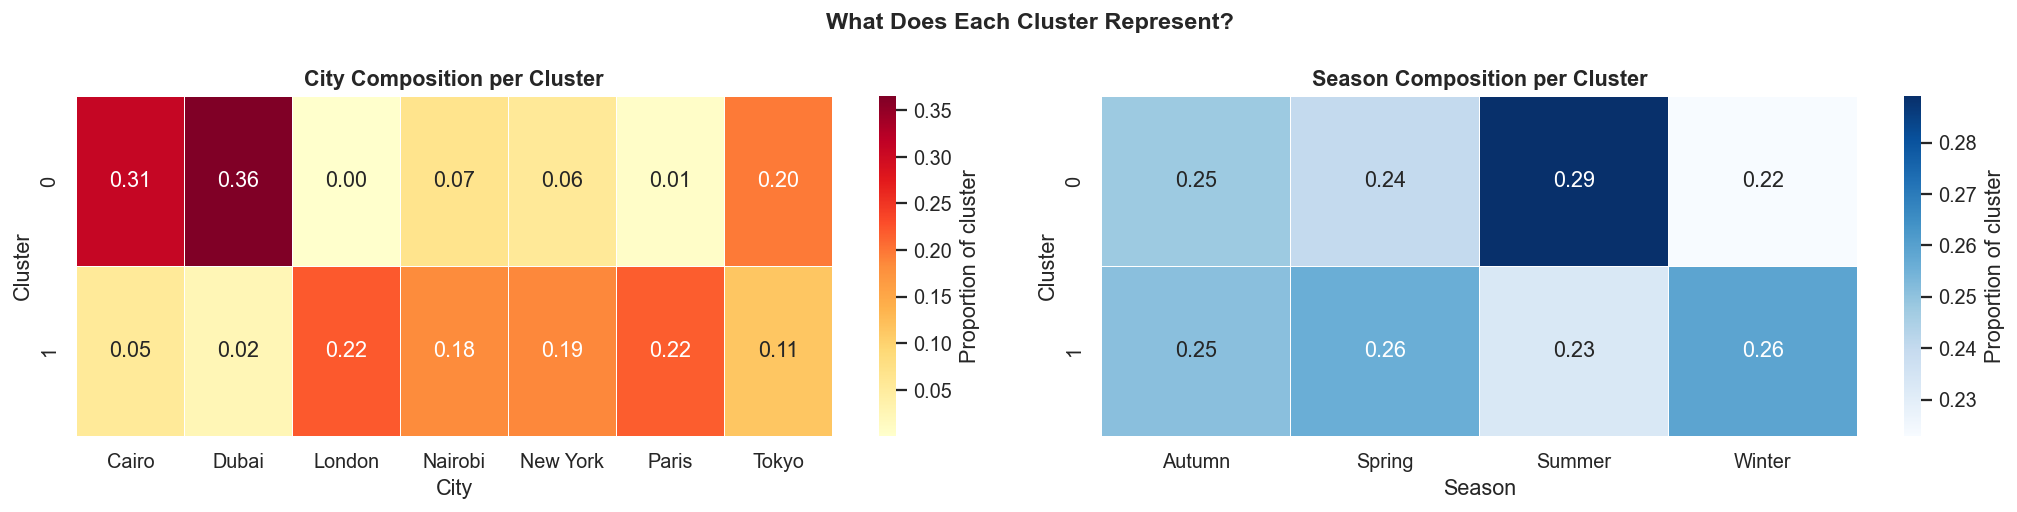

City composition per cluster:
City     Cairo  Dubai  London  Nairobi  New York  Paris  Tokyo
Cluster                                                       
0        0.309  0.365   0.001    0.067     0.056  0.006  0.197
1        0.054  0.024   0.220    0.183     0.187  0.218  0.114

Mean Humidity per cluster:
Cluster
0   57.530
1   68.450


In [ ]:
# Full results including train set for richer interpretation
all_labels = np.concatenate([train_labels, test_labels])
all_meta = pd.concat([meta_train, meta_test], ignore_index=True)
all_hum = pd.concat([y_train, y_test], ignore_index=True)
all_meta['Cluster'] = all_labels
all_meta['Humidity'] = all_hum

# City composition
city_ct = pd.crosstab(
 all_meta['Cluster'], all_meta['City'], normalize='index'
).round(3)

# Season composition
season_ct = pd.crosstab(
 all_meta['Cluster'], all_meta['Season'], normalize='index'
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(city_ct, annot=True, fmt='.2f', cmap='YlOrRd',
 linewidths=0.5, ax=axes[0],
 cbar_kws={'label': 'Proportion of cluster'})
axes[0].set_title('City Composition per Cluster', fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Cluster')

sns.heatmap(season_ct, annot=True, fmt='.2f', cmap='Blues',
 linewidths=0.5, ax=axes[1],
 cbar_kws={'label': 'Proportion of cluster'})
axes[1].set_title('Season Composition per Cluster', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Cluster')

plt.suptitle('What Does Each Cluster Represent?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('City composition per cluster:')
print(city_ct.to_string())
print('\nMean Humidity per cluster:')
print(all_meta.groupby('Cluster')['Humidity'].mean().round(2).to_string())

## Cell 10 — Centroid Feature Profiles

Shows what the average environmental day looks like in each cluster 
in original units — the pattern the model learned to distinguish clusters.

Cluster centroids (original units) + Humidity prediction:
           PM2.5     O3    NO2      CO    SO2  Temperature_mean  Wind_speed  Predicted_Humidity
Cluster 0 35.420 61.440 50.350 472.670 29.850            24.980      12.480              57.470
Cluster 1 12.540 50.830 23.870 266.640  6.210            15.810      14.430              68.310


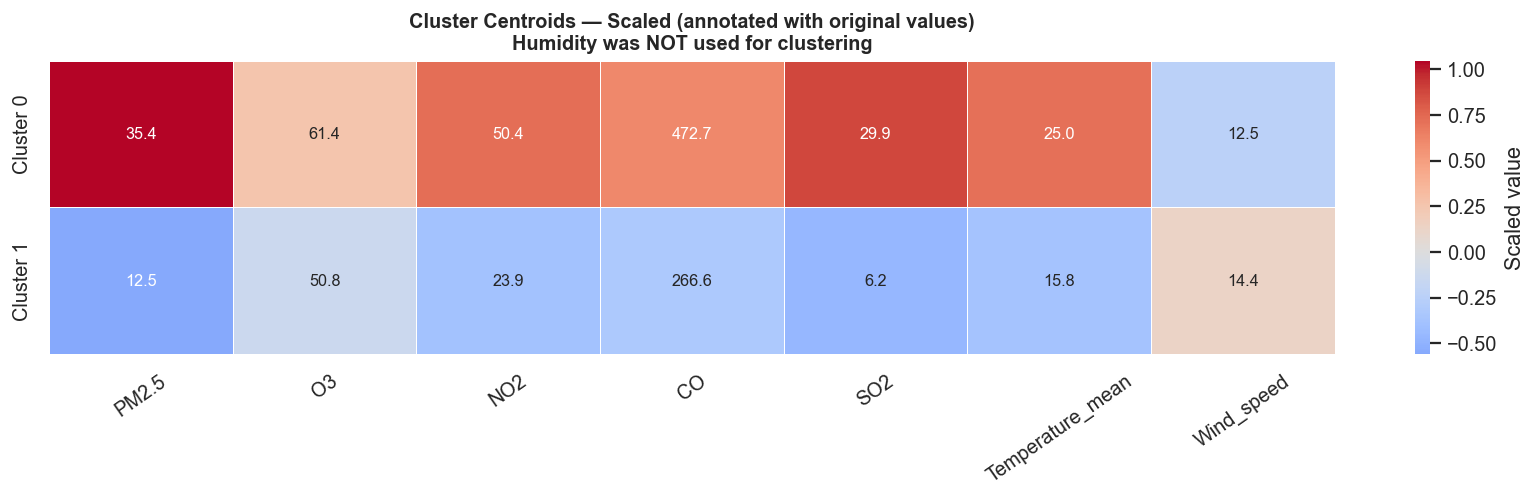

In [ ]:
centroids_original = scaler.inverse_transform(km_model.cluster_centers_)
centroids_df = pd.DataFrame(
 centroids_original,
 columns=FEATURES,
 index=[f'Cluster {i}' for i in range(OPTIMAL_K)]
).round(2)

# Add the Humidity prediction per cluster
centroids_df['Predicted_Humidity'] = [humidity_map[i] for i in range(OPTIMAL_K)]

print('Cluster centroids (original units) + Humidity prediction:')
print(centroids_df.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(13, 4))
centroids_norm = pd.DataFrame(
 km_model.cluster_centers_,
 columns=FEATURES,
 index=[f'Cluster {i}' for i in range(OPTIMAL_K)]
)
sns.heatmap(
 centroids_norm, annot=centroids_df[FEATURES], fmt='.1f',
 cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
 annot_kws={'size': 9}, cbar_kws={'label': 'Scaled value'}
)
ax.set_title('Cluster Centroids — Scaled (annotated with original values)\nHumidity was NOT used for clustering',
 fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## Cell 11 — PCA Visualization Colored by Predicted Humidity

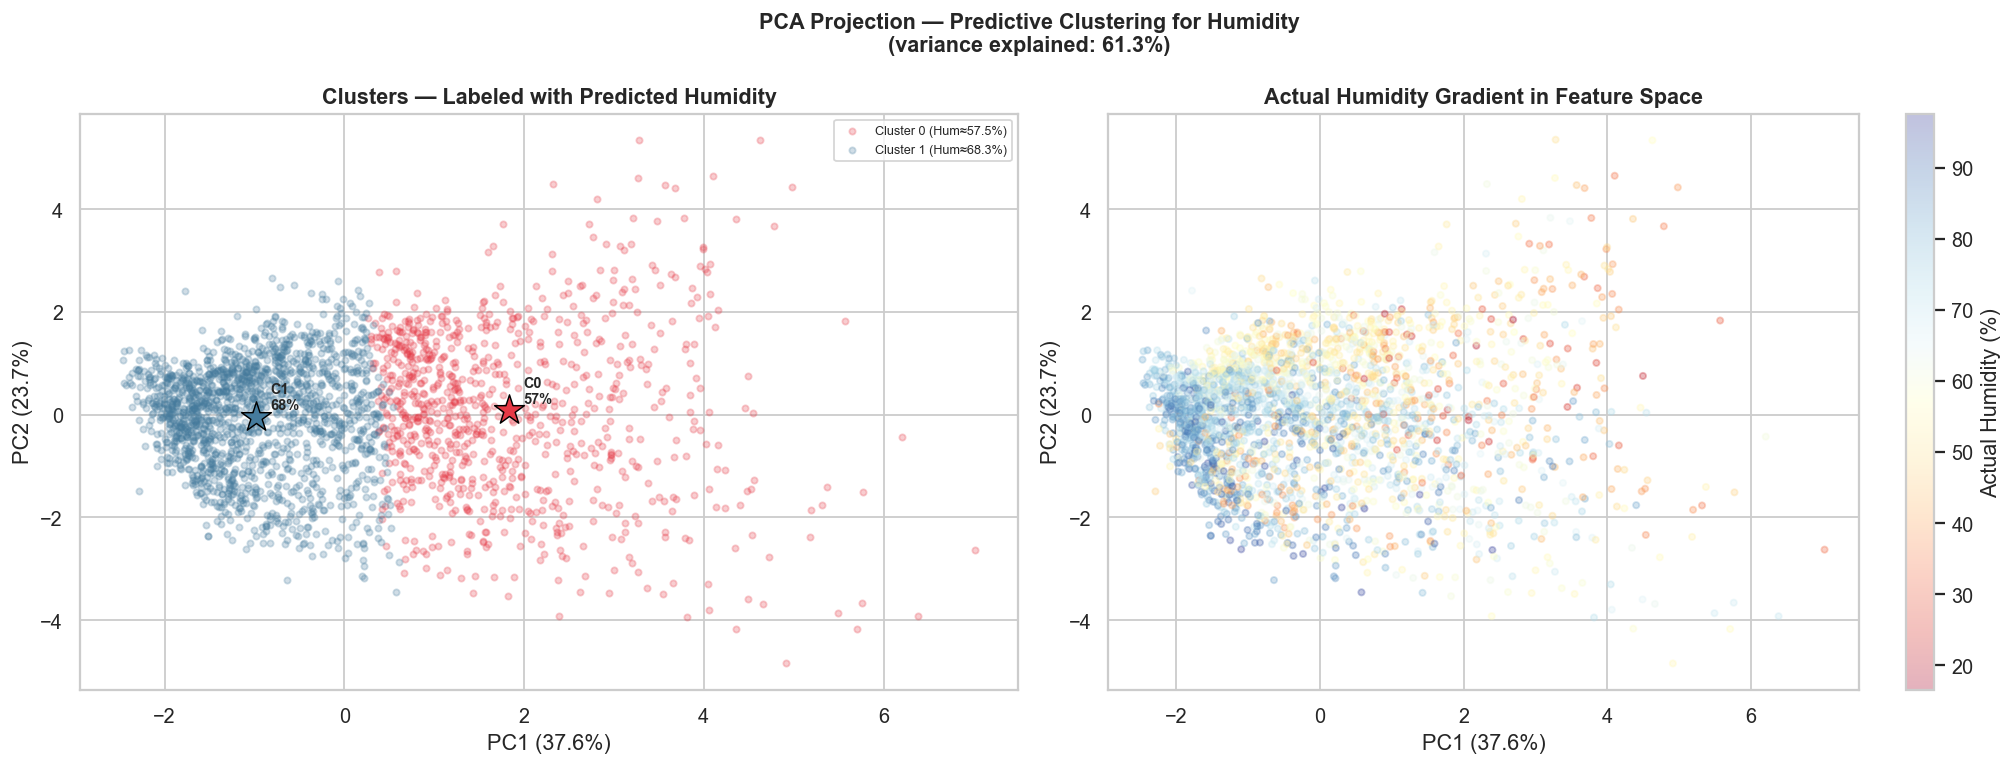

Variance explained: 61.3%


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_all = np.vstack([X_train, X_test])
coords = pca.fit_transform(X_all)
explained = pca.explained_variance_ratio_ * 100

all_pred_hum = np.array([humidity_map[c] for c in all_labels])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by cluster
cluster_colors = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261',
 '#8338EC', '#FB8500', '#06D6A0', '#264653']
for c in range(OPTIMAL_K):
 mask = all_labels == c
 axes[0].scatter(coords[mask, 0], coords[mask, 1],
 color=cluster_colors[c], alpha=0.25, s=12,
 label=f'Cluster {c} (Hum≈{humidity_map[c]:.1f}%)')
centroid_coords = pca.transform(km_model.cluster_centers_)
for c in range(OPTIMAL_K):
 axes[0].scatter(centroid_coords[c, 0], centroid_coords[c, 1],
 color=cluster_colors[c], s=300, marker='*',
 edgecolor='black', linewidth=0.8, zorder=5)
 axes[0].annotate(f'C{c}\n{humidity_map[c]:.0f}%',
 centroid_coords[c], fontsize=8, fontweight='bold',
 textcoords='offset points', xytext=(8, 4))
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].set_title('Clusters — Labeled with Predicted Humidity', fontweight='bold')
axes[0].legend(fontsize=7, loc='upper right')

# Colored by actual humidity gradient
all_actual_hum = pd.concat([y_train, y_test], ignore_index=True).values
sc = axes[1].scatter(coords[:, 0], coords[:, 1],
 c=all_actual_hum, cmap='RdYlBu',
 alpha=0.3, s=12)
plt.colorbar(sc, ax=axes[1], label='Actual Humidity (%)')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].set_title('Actual Humidity Gradient in Feature Space', fontweight='bold')

plt.suptitle(f'PCA Projection — Predictive Clustering for Humidity\n'
 f'(variance explained: {sum(explained):.1f}%)',
 fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Variance explained: {sum(explained):.1f}%')

## Cell 12 — Predict Humidity for a New Record

Provide a new daily record with all features **except Humidity**.
The model assigns it to the nearest centroid and returns 
the predicted Humidity with confidence and uncertainty bounds.

In [ ]:
# Cluster names — update after inspecting Cell 9
# Example: CLUSTER_NAMES = {0: 'Hot Arid', 1: 'Clean Temperate', ...}
CLUSTER_NAMES = {i: f'Cluster {i}' for i in range(OPTIMAL_K)}

# Within-cluster Humidity std (uncertainty bounds)
humidity_std_map = hum_df_train.groupby('Cluster')['Humidity'].std().to_dict()

def predict_humidity(record: dict, verbose: bool = True) -> dict:
 """
 Predict Humidity for a new daily record using K-Means.

 Parameters
 ----------
 record : dict with keys matching FEATURES (no Humidity needed)
 verbose : print full breakdown if True

 Returns
 -------
 dict with predicted humidity, cluster, confidence, uncertainty
 """
 row = pd.DataFrame([record])[FEATURES]
 row_scaled = scaler.transform(row)

 cluster = km_model.predict(row_scaled)[0]
 dists = pairwise_distances(row_scaled, km_model.cluster_centers_)[0]
 confidence = 1 - (dists[cluster] / dists.sum())

 pred_hum = humidity_map[cluster]
 pred_std = humidity_std_map[cluster]
 lower_bound = pred_hum - pred_std
 upper_bound = pred_hum + pred_std

 if verbose:
 print('=' * 55)
 print('HUMIDITY PREDICTION')
 print('=' * 55)
 print(f'Assigned Cluster : {cluster} — {CLUSTER_NAMES[cluster]}')
 print(f'Confidence : {confidence:.1%}')
 print(f'Predicted Humidity : {pred_hum:.1f}%')
 print(f'Uncertainty (±1 std): {pred_std:.1f}%')
 print(f'Likely range : {lower_bound:.1f}% — {upper_bound:.1f}%')
 print()
 print('Distance to each centroid:')
 for i, d in enumerate(dists):
 marker = ' ◄ ASSIGNED' if i == cluster else ''
 print(f' Cluster {i} ({CLUSTER_NAMES[i]}): dist={d:.3f}, '
 f'predicted_hum={humidity_map[i]:.1f}%{marker}')
 if confidence < 0.35:
 print()
 print('⚠️ LOW CONFIDENCE — record sits near a cluster boundary.')
 print(' Humidity prediction may be unreliable.')

 return {
 'cluster' : int(cluster),
 'cluster_name' : CLUSTER_NAMES[cluster],
 'predicted_humidity': round(pred_hum, 2),
 'uncertainty_std' : round(pred_std, 2),
 'lower_bound' : round(lower_bound, 2),
 'upper_bound' : round(upper_bound, 2),
 'confidence' : round(confidence, 4)
 }

# ── Example 1: Hot, polluted day (expect low humidity) ────────────────────
print('--- Example 1: Hot polluted day (expect low humidity) ---')
predict_humidity({
 'PM2.5' : 42.0,
 'O3' : 85.0,
 'NO2' : 55.0,
 'CO' : 450.0,
 'SO2' : 28.0,
 'Temperature_mean': 34.0,
 'Wind_speed' : 12.0
})

print()
# ── Example 2: Cool, clean day (expect high humidity) ─────────────────────
print('--- Example 2: Cool clean day (expect high humidity) ---')
predict_humidity({
 'PM2.5' : 7.0,
 'O3' : 42.0,
 'NO2' : 16.0,
 'CO' : 185.0,
 'SO2' : 2.0,
 'Temperature_mean': 11.0,
 'Wind_speed' : 16.0
})

--- Example 1: Hot polluted day (expect low humidity) ---
HUMIDITY PREDICTION
Assigned Cluster    : 0 — Cluster 0
Confidence          : 72.0%
Predicted Humidity  : 57.5%
Uncertainty (±1 std): 14.4%
Likely range        : 43.0% — 71.9%

Distance to each centroid:
  Cluster 0 (Cluster 0): dist=1.491, predicted_hum=57.5% ◄ ASSIGNED
  Cluster 1 (Cluster 1): dist=3.844, predicted_hum=68.3%

--- Example 2: Cool clean day (expect high humidity) ---
HUMIDITY PREDICTION
Assigned Cluster    : 1 — Cluster 1
Confidence          : 79.1%
Predicted Humidity  : 68.3%
Uncertainty (±1 std): 14.1%
Likely range        : 54.3% — 82.4%

Distance to each centroid:
  Cluster 0 (Cluster 0): dist=3.745, predicted_hum=57.5%
  Cluster 1 (Cluster 1): dist=0.989, predicted_hum=68.3% ◄ ASSIGNED


{'cluster': 1,
 'cluster_name': 'Cluster 1',
 'predicted_humidity': 68.31,
 'uncertainty_std': 14.05,
 'lower_bound': 54.26,
 'upper_bound': 82.36,
 'confidence': np.float64(0.791)}

## Cell 13 — Batch Prediction

In [ ]:
def predict_humidity_batch(records: list) -> pd.DataFrame:
 """
 Predict Humidity for multiple records at once.

 Parameters
 ----------
 records : list of dicts, each with keys matching FEATURES

 Returns
 -------
 DataFrame with predicted humidity, cluster, confidence, bounds
 """
 rows = pd.DataFrame(records)[FEATURES]
 scaled = scaler.transform(rows)
 clusters = km_model.predict(scaled)
 dists = pairwise_distances(scaled, km_model.cluster_centers_)
 dist_assign = dists[np.arange(len(clusters)), clusters]
 confidence = 1 - (dist_assign / dists.sum(axis=1))

 out = rows.copy().reset_index(drop=True)
 out['Cluster'] = clusters
 out['Cluster_Name'] = [CLUSTER_NAMES[c] for c in clusters]
 out['Predicted_Humidity'] = [round(humidity_map[c], 2) for c in clusters]
 out['Uncertainty_Std'] = [round(humidity_std_map[c], 2) for c in clusters]
 out['Lower_Bound'] = (out['Predicted_Humidity'] - out['Uncertainty_Std']).round(2)
 out['Upper_Bound'] = (out['Predicted_Humidity'] + out['Uncertainty_Std']).round(2)
 out['Confidence'] = confidence.round(4)
 out['Low_Confidence'] = confidence < 0.35
 return out

# ── Batch example ─────────────────────────────────────────────────────────
batch = [
 {'PM2.5': 42.0, 'O3': 85.0, 'NO2': 55.0, 'CO': 450.0,
 'SO2': 28.0, 'Temperature_mean': 34.0, 'Wind_speed': 12.0},
 {'PM2.5': 7.0, 'O3': 42.0, 'NO2': 16.0, 'CO': 185.0,
 'SO2': 2.0, 'Temperature_mean': 11.0, 'Wind_speed': 16.0},
 {'PM2.5': 20.0, 'O3': 55.0, 'NO2': 30.0, 'CO': 310.0,
 'SO2': 12.0, 'Temperature_mean': 22.0, 'Wind_speed': 10.0},
 {'PM2.5': 15.0, 'O3': 60.0, 'NO2': 12.0, 'CO': 560.0,
 'SO2': 5.0, 'Temperature_mean': 21.0, 'Wind_speed': 14.0},
]

batch_out = predict_humidity_batch(batch)
print('Batch Humidity Predictions:')
print(batch_out[['PM2.5', 'Temperature_mean', 'Cluster_Name',
 'Predicted_Humidity', 'Lower_Bound', 'Upper_Bound',
 'Confidence', 'Low_Confidence']].to_string(index=False))

Batch Humidity Predictions:
 PM2.5  Temperature_mean Cluster_Name  Predicted_Humidity  Lower_Bound  Upper_Bound  Confidence  Low_Confidence
42.000            34.000    Cluster 0              57.470       43.020       71.920       0.721           False
 7.000            11.000    Cluster 1              68.310       54.260       82.360       0.791           False
20.000            22.000    Cluster 1              68.310       54.260       82.360       0.600           False
15.000            21.000    Cluster 1              68.310       54.260       82.360       0.625           False


## Cell 14 — Summary

```
What this notebook does:

TARGET   : Humidity (%)
FEATURES : PM2.5, O3, NO2, CO, SO2, Temperature_mean, Wind_speed
           (Humidity deliberately excluded from all clustering steps)

Prediction mechanism:
  1. K-Means fits on 7 features (train set only)
  2. Mean Humidity per cluster computed from training data
  3. New record → assign to nearest centroid → predict its Humidity
  4. Uncertainty = within-cluster Humidity std
  5. Confidence = distance ratio to nearest centroid

Evaluation (test set, unseen during training):
  MAE  = mean absolute error in % humidity
  RMSE = root mean squared error in % humidity
  R²   = variance explained vs naive baseline (always predict mean)

The model answers:
  'Given pollution and temperature readings for a new day,
   what is the estimated humidity?'
```

## Cell 15 — k Comparison: MAE & RMSE Across k=2 to 9

Runs the full predictive clustering pipeline independently for each k:
fit on train → compute cluster Humidity means → predict on test → evaluate.
Produces an exact accuracy comparison table and visualization.

In [ ]:
k_comparison = []
baseline_mae = mean_absolute_error(y_test.values, np.full(len(y_test), y_train.mean()))
baseline_rmse = np.sqrt(mean_squared_error(y_test.values, np.full(len(y_test), y_train.mean())))

for k in range(2, 10):
 km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
 train_lbl_k = km_k.fit_predict(X_train)

 hum_df_k = pd.DataFrame({'Cluster': train_lbl_k, 'Humidity': y_train.values})
 hum_map_k = hum_df_k.groupby('Cluster')['Humidity'].mean().to_dict()
 hum_std_k = hum_df_k.groupby('Cluster')['Humidity'].std().mean()

 test_lbl_k = km_k.predict(X_test)
 pred_hum_k = np.array([hum_map_k[c] for c in test_lbl_k])
 actual_hum = y_test.values

 mae_k = mean_absolute_error(actual_hum, pred_hum_k)
 rmse_k = np.sqrt(mean_squared_error(actual_hum, pred_hum_k))
 ss_res = np.sum((actual_hum - pred_hum_k) ** 2)
 ss_tot = np.sum((actual_hum - actual_hum.mean()) ** 2)
 r2_k = 1 - (ss_res / ss_tot)
 sil_k = silhouette_score(X_train, train_lbl_k, sample_size=500, random_state=42)

 k_comparison.append({
 'k' : k,
 'MAE (%)' : round(mae_k, 4),
 'RMSE (%)' : round(rmse_k, 4),
 'R2' : round(r2_k, 4),
 'Silhouette' : round(sil_k, 4),
 'Mean Within-Std (%)' : round(hum_std_k, 4),
 'MAE vs Baseline' : round(baseline_mae - mae_k, 4),
 'Better than baseline' : mae_k < baseline_mae
 })

comp_df = pd.DataFrame(k_comparison).set_index('k')

print(f'Baseline MAE (always predict mean): {baseline_mae:.4f}%')
print(f'Baseline RMSE (always predict mean): {baseline_rmse:.4f}%')
print()
print('=== Full k Comparison ===')
print(comp_df.to_string())
print()

best_mae_k = comp_df['MAE (%)'].idxmin()
best_rmse_k = comp_df['RMSE (%)'].idxmin()
best_r2_k = comp_df['R2'].idxmax()
print(f'Best k by MAE : k={best_mae_k} (MAE={comp_df.loc[best_mae_k, "MAE (%)"]:,.4f}%)')
print(f'Best k by RMSE : k={best_rmse_k} (RMSE={comp_df.loc[best_rmse_k, "RMSE (%)"]:,.4f}%)')
print(f'Best k by R2 : k={best_r2_k} (R2={comp_df.loc[best_r2_k, "R2"]:,.4f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_vals = comp_df.index.tolist()

axes[0].plot(k_vals, comp_df['MAE (%)'], marker='o', linewidth=2, markersize=8, color='#E63946', label='Cluster model')
axes[0].axhline(baseline_mae, color='grey', linestyle='--', linewidth=1.5, label=f'Baseline: {baseline_mae:.2f}%')
axes[0].scatter([best_mae_k], [comp_df.loc[best_mae_k, 'MAE (%)']], color='gold', s=200, zorder=5, edgecolor='black', linewidth=1, label=f'Best: k={best_mae_k}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('MAE (%)')
axes[0].set_title('MAE vs k', fontweight='bold')
axes[0].set_xticks(k_vals)
axes[0].legend(fontsize=8)

axes[1].plot(k_vals, comp_df['RMSE (%)'], marker='s', linewidth=2, markersize=8, color='#457B9D', label='Cluster model')
axes[1].axhline(baseline_rmse, color='grey', linestyle='--', linewidth=1.5, label=f'Baseline: {baseline_rmse:.2f}%')
axes[1].scatter([best_rmse_k], [comp_df.loc[best_rmse_k, 'RMSE (%)']], color='gold', s=200, zorder=5, edgecolor='black', linewidth=1, label=f'Best: k={best_rmse_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('RMSE (%)')
axes[1].set_title('RMSE vs k', fontweight='bold')
axes[1].set_xticks(k_vals)
axes[1].legend(fontsize=8)

axes[2].plot(k_vals, comp_df['R2'], marker='^', linewidth=2, markersize=8, color='#2A9D8F', label='Cluster model')
axes[2].axhline(0, color='grey', linestyle='--', linewidth=1.5, label='Baseline R2=0')
axes[2].scatter([best_r2_k], [comp_df.loc[best_r2_k, 'R2']], color='gold', s=200, zorder=5, edgecolor='black', linewidth=1, label=f'Best: k={best_r2_k}')
axes[2].set_xlabel('k')
axes[2].set_ylabel('R2')
axes[2].set_title('R2 vs k', fontweight='bold')
axes[2].set_xticks(k_vals)
axes[2].legend(fontsize=8)

plt.suptitle('Humidity Prediction Accuracy vs k — Full Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMAE improvement over baseline per k:')
for k, row in comp_df.iterrows():
 diff = baseline_mae - row['MAE (%)']
 pct = diff / baseline_mae * 100
 marker = ' <- BEST' if k == best_mae_k else ''
 sign = '+' if diff >= 0 else ''
 print(f' k={k}: MAE={row["MAE (%)"]:6.3f}% ({sign}{diff:.3f}% vs baseline, {sign}{pct:.1f}%){marker}')

## Final Insights

### Predictive Clustering
- K-Means clustering identified distinct environmental conditions associated with humidity behavior.
- Cluster-based humidity estimation generated meaningful environmental approximations.
- PCA visualization confirmed reasonable cluster separation.

### Seasonal Clustering
- Seasonal environmental conditions formed distinguishable clusters based on pollutants and weather variables.
- Correlation analysis revealed meaningful relationships between environmental indicators.
- Hierarchical clustering highlighted recurring seasonal patterns.

### City Clustering
- Cities were grouped according to environmental similarity rather than geographic proximity.
- Cluster centroids revealed differences in pollution concentration and climate behavior.
- Hierarchical clustering identified long-term environmental similarity between cities.

### Overall Conclusion
- Clustering revealed meaningful latent environmental structures within the dataset.
- Environmental and atmospheric variables contained distinguishable patterns that support environmental monitoring and exploratory prediction tasks.